
# Pedestrian Deaths while Smart Phone Ownership

## Load the various utility libraries to setup the notebook

In [11]:

import os.path as osp, os as os
shared_folder = osp.abspath(osp.join(os.pardir, 'share')); assert osp.exists(shared_folder)
import sys
if shared_folder not in sys.path: sys.path.insert(1, shared_folder)
from notebook_utils import NotebookUtilities
nu = NotebookUtilities(
    data_folder_path=osp.abspath(osp.join(os.pardir, 'data')),
    saves_folder_path=osp.abspath(osp.join(os.pardir, 'saves'))
)

# Import needed libraries
from datetime import datetime
from pandas import DataFrame
from scipy.optimize import fsolve, curve_fit
import locale, re
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
%matplotlib inline

# Use the following only if you are on a high definition device
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

# Add python folder to system path and reuglify print
sys.path.insert(1, osp.abspath(osp.join(os.pardir, 'py')))
%pprint

Pretty printing has been turned ON



## Mobile phone ownership (% of U.S. adults who say they own a mobile or smart phone) over time

The vast majority of Americans – 98% – now own a cellphone of some kind. About nine-in-ten (91%) own a smartphone, up from just 35% in the Center’s first survey of smartphone ownership conducted in 2011.

In [22]:

# https://www.pewresearch.org/internet/fact-sheet/mobile/
import pandas as pd

file_path = "../data/csv/mobile_phone_ownership_data_2024-11-13.csv"
smartphones_df = pd.read_csv(file_path)
smartphones_df.columns = ["Date", "Cellphone", "Smartphone"]

# Convert "Date" to datetime (pandas auto-detects formats like 10/27/2002)
smartphones_df["Date"] = pd.to_datetime(smartphones_df["Date"], errors="coerce")

# Remove % and convert to floats between 0.0 and 1.0
for col in ["Cellphone", "Smartphone"]:
    smartphones_df[col] = (
        smartphones_df[col]
        .astype(str)          # make sure they’re strings
        .str.replace("%", "", regex=False)  # remove %
        .str.strip()          # trim whitespace
        .replace("", None)    # turn empty strings into NaN
        .astype(float) / 100  # scale to 0.0–1.0
    )

# Get the year from the date
smartphones_df["Year"] = smartphones_df["Date"].map(lambda x: x.year)

print(smartphones_df.dtypes)
display(smartphones_df.sample(5))

Date          datetime64[ns]
Cellphone            float64
Smartphone           float64
Year                   int64
dtype: object


,Date,Cellphone,Smartphone,Year
41,2013-01-06,0.89,0.51,2013
49,2014-01-12,0.90,0.58,2014
36,2012-10-14,0.88,NaN,2012
62,2019-02-07,0.96,0.81,2019
34,2012-09-23,0.88,0.43,2012



## Pedestrian fatalities and pedestrian fatalities as a percent of all traffic fatalities, 1994-2023

National Safety Council analysis of NHTSA pedestrian traffic fatality data shows a general decline in the number of pedestrian fatalities from 1994 through 2009. Starting in 2010, pedestrian fatalities have been trending up. In 2023, pedestrian deaths decreased for the first time since 2019, with an improvement of 3.7% from 2022. Pedestrian fatalities as a percent of all traffic fatalities increased steadily from 2005 through 2018, from 11.2% to 17.3%, respectively. The percentage of pedestrian deaths has now increased for three consecutive years, accounting for 17.9% in 2023.

In [21]:

# https://injuryfacts.nsc.org/motor-vehicle/road-users/pedestrians/data-details/
import pandas as pd

file_path = "../data/xlsx/Pedestrian Tables.xlsx"

# Read the Excel sheet, using the third row (index 2) as the header
pedestrians_df = pd.read_excel(file_path, sheet_name="Year", header=2)

# Coerce 'Year' to numeric, turning any non-numeric values into NaN
pedestrians_df["Year"] = pd.to_numeric(pedestrians_df["Year"], errors="coerce").astype("Int64")

# Drop rows where 'Year' is NaN (after coercion)
pedestrians_df = pedestrians_df.dropna(subset=["Year"])

print(pedestrians_df.dtypes)
display(pedestrians_df.sample(5))

Year                                                           Int64
Pedestrian fatalities                                        float64
Pedestrian fatalities as a percent all traffic fatalities    float64
dtype: object


,Year,Pedestrian fatalities,Pedestrian fatalities as a percent all traffic fatalities
22,2015,5495.0,0.1549
1,1994,5489.0,0.1348
5,1998,5228.0,0.1260
20,2013,4779.0,0.1453
16,2009,4109.0,0.1213


,Pedestrian fatalities
Year,
1994,5489.0
1995,5584.0
1996,5449.0
1997,5321.0
1998,5228.0
1999,4939.0
2000,4763.0
2001,4901.0
2002,4851.0


In [25]:

import pandas as pd

# Group and average by Year, then drop unnecessary columns
smartphones_yearly = (
    smartphones_df
    .groupby("Year", as_index=False)
    .mean(numeric_only=True)
    .drop(columns=["Date"], errors="ignore")
)

pedestrians_yearly = (
    pedestrians_df
    .groupby("Year", as_index=False)
    .mean(numeric_only=True)
    .drop(columns=["Pedestrian fatalities as a percent all traffic fatalities"], errors="ignore")
)

# Merge on the 'Year' column (common key)
merged_df = pd.merge(
    smartphones_yearly,
    pedestrians_yearly,
    on="Year",
    how="inner"   # change to 'outer' if you want all years from both datasets
)

display(merged_df.sample(5))

,Year,Cellphone,Smartphone,Pedestrian fatalities
6,2009,0.842500,NaN,4109.0
14,2018,0.950000,0.77,6374.0
15,2019,0.960000,0.81,6272.0
12,2015,0.916667,0.68,5495.0
13,2016,0.930000,0.73,6080.0


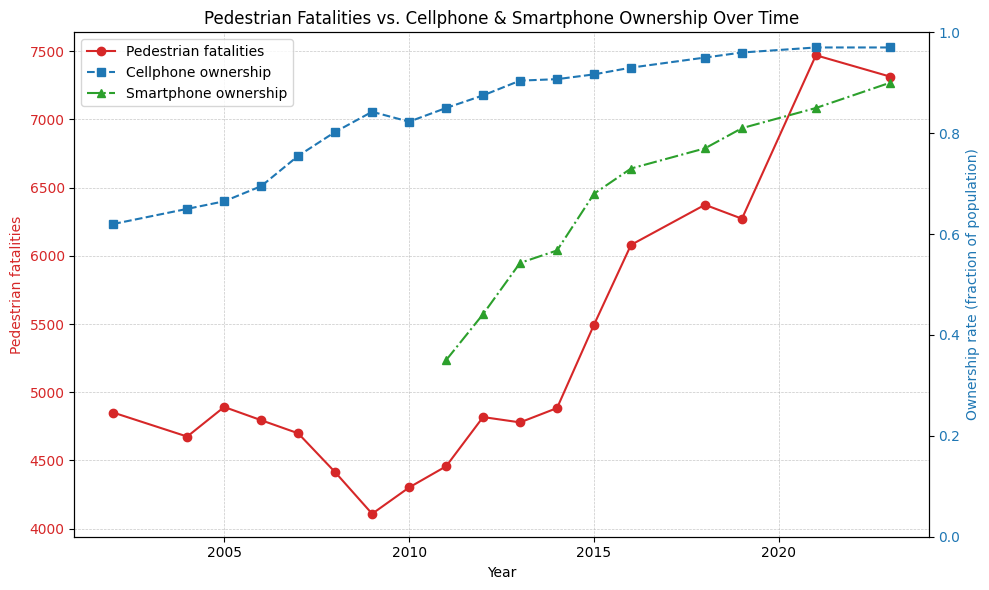

In [26]:

import matplotlib.pyplot as plt

# Create the figure and twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: Pedestrian fatalities
ax1.plot(
    merged_df["Year"],
    merged_df["Pedestrian fatalities"],
    color="tab:red",
    marker="o",
    label="Pedestrian fatalities"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Pedestrian fatalities", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

# Right y-axis: Cellphone and Smartphone adoption
ax2 = ax1.twinx()
ax2.plot(
    merged_df["Year"],
    merged_df["Cellphone"],
    color="tab:blue",
    marker="s",
    linestyle="--",
    label="Cellphone ownership"
)
ax2.plot(
    merged_df["Year"],
    merged_df["Smartphone"],
    color="tab:green",
    marker="^",
    linestyle="-.",
    label="Smartphone ownership"
)
ax2.set_ylabel("Ownership rate (fraction of population)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_ylim(0, 1)  # since cellphone/smartphone are fractions 0–1

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

# Add title and grid
plt.title("Pedestrian Fatalities vs. Cellphone & Smartphone Ownership Over Time")
ax1.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()